# Predicción de rayos en Colombia con WWLLN
## Informe técnico — pipeline, modelos, métricas y resultados

**Autor:** Manuel Fernando Valle Amortegui  
**Dataset:** World Wide Lightning Location Network (WWLLN) — 518 días  
**Objetivo:** Predecir la probabilidad de ocurrencia de rayos en Colombia
a +30 minutos de anticipación, en una grilla espacial de 0.25° (~28 km).

## 1. Definición del problema

Colombia es uno de los países con mayor actividad eléctrica del mundo.
Su geografía (cordillera de los Andes, llanuras orientales, costa Pacífica)
combinada con la Zona de Convergencia Intertropical (ITCZ) genera condiciones
de convección extrema durante gran parte del año.

Los rayos representan un riesgo real:
- Muertes directas e indirectas
- Daño a infraestructura eléctrica y de telecomunicaciones
- Riesgo en aviación
- Incendios forestales

### Pregunta científica

> Dado el historial reciente de descargas eléctricas en una región,
> ¿es posible predecir si habrá rayos en los próximos 30 minutos?

### Formulación como problema de ML

Para cada celda geográfica de Colombia en cada instante de tiempo:

  Entrada  : historial de actividad de rayos en los últimos 60 minutos
  Salida   : P(rayo en esa celda en los próximos 30 minutos) ∈ [0, 1]

Es un problema de **clasificación binaria espacio-temporal** con
fuerte desbalance de clases: solo el ~0.57% de los bins tienen actividad.

## 2. Fuente de datos: WWLLN

### ¿Qué es WWLLN?

La **World Wide Lightning Location Network** es una red científica de
aproximadamente 50 sensores distribuidos globalmente. Cada sensor detecta
la señal electromagnética (sferic) emitida por una descarga eléctrica.
Cuando múltiples sensores detectan la misma señal, el sistema triangula
la posición del rayo con precisión de ~10 km y ~10 µs.

El acceso a los datos es académico/institucional.

### Tipo de dato: stroke

Cada evento registrado es un **stroke** — una descarga eléctrica individual.
Un rayo visible puede contener múltiples strokes (típicamente 3-5).

### Formato de archivo: AE*.loc

Los archivos AE (Advanced Energy) contienen 9 columnas por evento:

  fecha, hora, lat, lon, resid, nsta, energy, energy_uncertainty, nsta_energy

Ejemplo de fila:
  2025/01/15, 14:32:07.483921, 4.7231, -74.0412, 18.3, 12, 2847.5, 312.1, 9

Donde:
  fecha/hora          : timestamp del stroke (resolución microsegundos)
  lat, lon            : posición geográfica (grados decimales)
  resid               : residuo temporal de la triangulación (µs) — calidad de la localización
  nsta                : número de estaciones que detectaron el evento
  energy              : energía estimada de la descarga (J/m)
  energy_uncertainty  : incertidumbre en la energía
  nsta_energy         : estaciones que contribuyeron al cálculo de energía

### Estadísticas del dataset

  Archivos procesados   : 518 días
  Total strokes Colombia: ~14.5 millones
  Promedio diario       : ~28,000 strokes/día
  Mínimo diario         : 74 strokes
  Máximo diario         : 120,464 strokes

## 3. Pipeline de procesamiento

Los archivos crudos contienen datos de todo el mundo. El primer paso
es reducir el volumen a solo Colombia.

### Etapa 1: Filtro por bounding box

Se aplica un filtro rápido por coordenadas antes de cualquier operación costosa:

  Latitud  : -5° a  15°
  Longitud : -80° a -66°

Esto reduce el volumen de datos en ~20× antes de cualquier operación costosa.
Script: prefilter_Colombia.py

### Etapa 2: Filtro geográfico preciso

Se usa un shapefile de departamentos de Colombia (GPKG) para hacer
point-in-polygon — solo se conservan strokes que caen dentro del
territorio colombiano real, no solo el bounding box.
Script: filter_Colombia.py

### Etapa 3: Orden temporal

Los eventos se ordenan cronológicamente por timestamp para garantizar
consistencia en la construcción de ventanas temporales.
Script: time_sorting.py

### Etapa 4: Conversión a Parquet

Los archivos .loc se convierten a formato Parquet:
- Lectura 10-50× más rápida que CSV
- Compresión eficiente
- Tipos de datos correctos (timestamp, float32)
Script: loc_to_parquet.py

### Etapa 5: Construcción de grids

Cada día se convierte en un tensor 3D:

  grid[t, i, j] = número de strokes en timestep t, celda (i,j)

Dimensiones:
  t : 96 timesteps de 15 min por día (0:00 a 23:45)
  i : 80 celdas de latitud  (0.25° × 80 = 20° → -5° a 15°)
  j : 56 celdas de longitud (0.25° × 56 = 14° → -80° a -66°)

Resultado: 518 archivos .npz, uno por día
Script: build_grids.py

## 4. Elección de resolución espacial y temporal

Antes de construir cualquier modelo se ejecutó un análisis exploratorio
para determinar la resolución óptima. La métrica clave es la
**occupancy espacio-temporal**: fracción de bins (celda, tiempo) que
tienen al menos un stroke.

### Resultados de explore_spacetime_density.py (ventana de 15 min)

  Resolución | Celdas totales | Occupancy espacial | Occupancy espacio-temporal | Strokes/bin
  -----------|----------------|-------------------|---------------------------|------------
  0.10°      | 28,000         | 35.3%             | 0.17%                     | 2.85
  0.20°      | 7,000          | 38.7%             | 0.42%                     | 4.60
  0.25°      | 4,480          | 39.6%             | 0.57%                     | 5.37  ← ELEGIDA
  0.30°      | 3,149          | 39.8%             | 0.71%                     | 6.12
  0.40°      | 1,750          | 41.9%             | 1.04%                     | 10.53

### Justificación de 0.25°

- 0.10° tiene solo 2.85 strokes por bin activo: demasiado ruidoso
- 0.40° equivale a ~44 km por celda: demasiado grueso para ser operacional
- 0.25° da 80×56 = 4,480 celdas: manejable para CNNs
- 0.25° tiene 5.37 strokes/bin activo: señal suficiente para aprender

### Justificación de 15 min

  Ventana temporal | Occupancy (0.25°)
  -----------------|------------------
  5 min            | 0.30%
  10 min           | 0.45%
  15 min           | 0.57%  ← ELEGIDA
  30 min           | 0.83%

Pasar de 15 a 30 min sube el occupancy de 0.57% a 0.83% (+46%),
pero se pierde la mitad de la resolución temporal. No vale la pena.

### Conclusión del análisis exploratorio

Incluso con 0.25° y 15 min, más del 99.4% de los bins están vacíos.
Esto confirma que el problema es de **rare event forecasting** y
requiere métricas y técnicas especiales para el desbalance de clases.

## 5. Definición formal de entrada y salida

### Para LightGBM (formato tabular)

Cada ejemplo es una fila en una tabla. Una fila = una celda geográfica
en un instante de tiempo específico.

ENTRADA — 12 features por ejemplo:

  Feature      | Tipo    | Descripción
  -------------|---------|---------------------------------------------
  count_t      | float32 | log(1 + strokes en t)      — timestep actual
  count_t1     | float32 | log(1 + strokes en t-1)    — 15 min atrás
  count_t2     | float32 | log(1 + strokes en t-2)    — 30 min atrás
  count_t3     | float32 | log(1 + strokes en t-3)    — 45 min atrás
  nbr_t        | float32 | log(1 + vecinos activos en t)
  nbr_t1       | float32 | log(1 + vecinos activos en t-1)
  nbr_t2       | float32 | log(1 + vecinos activos en t-2)
  nbr_t3       | float32 | log(1 + vecinos activos en t-3)
  lat_idx      | int     | índice de latitud de la celda (0–79)
  lon_idx      | int     | índice de longitud de la celda (0–55)
  hour_sin     | float32 | sin(2π × hora/96) — componente cíclica
  hour_cos     | float32 | cos(2π × hora/96) — componente cíclica

SALIDA — 1 valor binario:

  y = 1  si grid[t+2, i, j] > 0  (habrá al menos 1 rayo en 30 min)
  y = 0  en caso contrario

Por qué log(1 + x):
  Los conteos de strokes tienen distribución muy sesgada (mayoría = 0,
  algunos bins con 100+). El logaritmo comprime la escala y mejora
  la estabilidad numérica del entrenamiento.

Por qué vecinos (nbr):
  Del análisis exploratorio:
  - Celda con vecino activo: 11.6% de probabilidad de tener rayo
  - Celda sin vecino activo: 0.19% de probabilidad
  → los vecinos activos multiplican la probabilidad por ~60×

Por qué hour_sin/cos en lugar de la hora directa:
  La hora es una variable cíclica: las 23:45 y las 00:00 están
  separadas por 15 min, no por 23h45m. La codificación sinusoidal
  preserva esta continuidad.

### Para ConvLSTM (formato tensorial)

Cada ejemplo es un tensor 4D. Un ejemplo = un mapa completo de Colombia
en 4 instantes consecutivos.

ENTRADA — tensor X de shape (4, 80, 56, 5):

  Dimensión 1: 4 timesteps (últimos 60 minutos)
  Dimensión 2: 80 celdas de latitud
  Dimensión 3: 56 celdas de longitud
  Dimensión 4: 5 canales

  Canal 0: log(1 + counts)           — actividad propia
  Canal 1: log(1 + vecinos 3×3)      — actividad vecinal
  Canal 2: latitud normalizada        — contexto geográfico
  Canal 3: longitud normalizada       — contexto geográfico
  Canal 4: sin(2π × hora/96)         — ciclo diurno

SALIDA — tensor y de shape (80, 56, 1):

  y[i, j, 0] = 1  si hay al menos 1 rayo en celda (i,j) en t+2
  y[i, j, 0] = 0  en caso contrario

  La red produce un MAPA COMPLETO de Colombia en cada paso,
  no una predicción por celda aislada. Esto permite capturar
  patrones de propagación espacial de tormentas.

## 6. Métricas de evaluación

### Por qué no usamos Accuracy

Con 0.57% de positivos, un modelo que predice siempre cero tiene:

  Accuracy = 99.43%

Este número es completamente inútil: el modelo no aprendió nada.
El problema exige métricas que evalúen específicamente el rendimiento
sobre los eventos raros (positivos).

### ROC-AUC (Area Under the ROC Curve)

La curva ROC enfrenta:
  Eje X: False Positive Rate = FP / (FP + TN)
  Eje Y: True Positive Rate  = TP / (TP + FN)

El AUC mide la probabilidad de que el modelo asigne una probabilidad
mayor a un positivo aleatorio que a un negativo aleatorio.

  AUC = 0.5  → clasificador aleatorio (sin información)
  AUC = 1.0  → clasificador perfecto
  AUC = 0.9  → muy bueno en separar positivos de negativos

Limitación: puede ser optimista con clases muy desbalanceadas,
porque hay muchos negativos fáciles que elevan el TN y bajan el FPR
artificialmente.

### PR-AUC (Area Under the Precision-Recall Curve)

La curva PR enfrenta:
  Eje X: Recall    = TP / (TP + FN)  ← de todos los rayos, ¿cuántos encontré?
  Eje Y: Precision = TP / (TP + FP)  ← de lo que predije como rayo, ¿cuánto era rayo?

El PR-AUC es la métrica principal de este proyecto porque:
1. Es sensible al desbalance: un clasificador aleatorio tiene PR-AUC ≈ 0.0057
2. Mide directamente la calidad sobre los eventos de interés (los rayos)
3. Un modelo que "hace trampa" prediciendo siempre cero tiene PR-AUC ≈ 0

Interpretación de resultados:
  PR-AUC ≈ 0.006  → clasificador aleatorio (baseline mínimo)
  PR-AUC ≈ 0.50   → modelo con señal moderada
  PR-AUC ≈ 0.90   → modelo muy fuerte
  PR-AUC = 0.917  → resultado obtenido con LightGBM (nuestro baseline)

### Threshold y matriz de confusión

El modelo produce probabilidades. La elección del threshold afecta el
balance precision/recall:

  Threshold alto → pocas alarmas, alta precisión, bajo recall
                   (apropiado si las falsas alarmas tienen costo alto)
  Threshold bajo → muchas alarmas, alto recall, menor precisión
                   (apropiado si perder un rayo tiene costo alto)

En aplicaciones operacionales de meteorología convectiva, generalmente
se prefiere un recall alto (no perder eventos peligrosos), lo que implica
un threshold más bajo que 0.5.

## 7. Modelo 1: LightGBM (baseline)

### ¿Por qué empezar con LightGBM?

En cualquier proyecto de ML es obligatorio construir un baseline sólido
antes de invertir tiempo en arquitecturas complejas. Si una red profunda
no supera el baseline, no hay justificación para usarla.

LightGBM es el estándar actual para datos tabulares porque:
- Entrena muy rápido (gradient boosting con histogramas)
- Maneja bien variables de distinta escala sin normalización
- scale_pos_weight compensa el desbalance de clases directamente
- Interpretable: importancia de variables por gain

### Arquitectura

LightGBM construye un ensemble de árboles de decisión de forma secuencial.
Cada árbol nuevo corrige los errores del ensemble anterior (boosting).
Los árboles crecen hoja por hoja (leaf-wise) en lugar de nivel por nivel,
lo que permite capturar interacciones complejas con menos árboles.

Parámetros clave usados:
  n_estimators    : 500   — número de árboles
  learning_rate   : 0.05  — tamaño del paso de cada árbol
  num_leaves      : 127   — complejidad máxima por árbol
  scale_pos_weight: ~175  — peso extra a los positivos (ratio negativo/positivo)
  subsample       : 0.8   — fracción de datos por árbol (regularización)
  colsample_bytree: 0.8   — fracción de features por árbol (regularización)

### Experimentos de ablación

Se entrenaron 4 modelos para aislar el aporte de cada grupo de variables:

  Experimento         | Features usadas         | ROC-AUC | PR-AUC
  --------------------|-------------------------|---------|-------
  A — Climatología    | lat, lon, hora          |  ?      |  ?
  B — Dinámica pura   | counts + vecinos        |  ?      |  ?
  C — Completo        | todas (12 features)     | 0.9823  | 0.9175
  D — Sin ubicación   | counts + nbr + hora     |  ?      |  ?

(Los experimentos A, B, D se ejecutan en las celdas siguientes)

### Importancia de variables (modelo completo, gain)

  lat_idx   : 8,235  ← la ubicación geográfica es el predictor más fuerte
  lon_idx   : 7,842
  nbr_t     : 2,056  ← actividad vecinal, segundo grupo más importante
  count_t   : 1,321  ← actividad propia reciente

### Resultado

  ROC-AUC  : 0.9823
  PR-AUC   : 0.9175
  Precision: 0.85
  Recall   : 0.85
  F1       : 0.85

### Interpretación

El PR-AUC de 0.917 es extraordinariamente alto para predicción de rayos
a corto plazo usando únicamente historial de descargas. Indica que la señal
predictiva es muy fuerte y está concentrada en dos patrones:

1. Climatología espacial: ciertas zonas de Colombia tienen rayos
   crónicamente más frecuentes (Pacífico, piedemonte llanero).

2. Persistencia local: si hubo rayos en una celda hace 15-30 min,
   es probable que los siga habiendo.

Este resultado establece el techo que la ConvLSTM debe superar.

## 8. Modelo 2: ConvLSTM multicanal

### ¿Por qué ConvLSTM?

LightGBM tiene una limitación fundamental: trata cada celda de forma
independiente. No puede aprender que una tormenta en Bogotá se desplaza
hacia Tunja, ni detectar patrones de propagación espacial complejos.

La ConvLSTM (Convolutional LSTM) combina dos capacidades:

1. Convoluciones espaciales (como en CNNs):
   Detectan patrones locales en el mapa (bordes de tormenta, gradientes
   de actividad, estructuras convectivas).

2. Memoria temporal (como en LSTMs):
   Recuerdan la evolución reciente del sistema (últimos 60 minutos)
   y capturan dependencias temporales de largo alcance.

Es la arquitectura estándar en nowcasting meteorológico (predicción
a muy corto plazo), introducida por Shi et al. (2015) específicamente
para predicción de precipitación en grilla.

### Diferencia conceptual con LightGBM

  LightGBM:
    - Ve: [count_t, count_t1, nbr_t, lat, lon, hora] para UNA celda
    - Predice: ¿habrá rayo en ESA celda?
    - Ventaja: muy eficiente, captura relaciones locales perfectamente
    - Limitación: no ve el mapa completo, no detecta propagación

  ConvLSTM:
    - Ve: mapa completo de Colombia en 4 instantes (4 × 80 × 56 × 5)
    - Predice: mapa completo de probabilidades (80 × 56)
    - Ventaja: captura patrones espaciales globales y propagación
    - Limitación: requiere más datos y tiempo de entrenamiento

### Arquitectura detallada

  Input:  (batch, 4, 80, 56, 5)
            │
            ▼
  ConvLSTM2D(32 filtros, kernel 3×3, return_sequences=True)
  + BatchNormalization
            │
            ▼ (batch, 4, 80, 56, 32)
            │
  ConvLSTM2D(32 filtros, kernel 3×3, return_sequences=False)
  + BatchNormalization
            │
            ▼ (batch, 80, 56, 32)
            │
  Conv2D(32 filtros, kernel 3×3, ReLU)
  + Dropout(0.2)
            │
            ▼ (batch, 80, 56, 32)
            │
  Conv2D(1 filtro, kernel 1×1, Sigmoid)
            │
            ▼
  Output: (batch, 80, 56, 1) — mapa de probabilidades

Capa por capa:
  ConvLSTM2D capa 1: procesa la secuencia temporal completa,
    devuelve un estado oculto por cada timestep (return_sequences=True).
    Captura cómo evoluciona la actividad eléctrica en el tiempo.

  ConvLSTM2D capa 2: consolida la secuencia en un único mapa de features
    (return_sequences=False). Resume la memoria temporal en una
    representación espacial.

  Conv2D(32): refina los patrones espaciales localmente.
    Actúa como un postprocesador espacial sobre la memoria temporal.

  Dropout(0.2): regularización. Apaga el 20% de las neuronas
    aleatoriamente durante el entrenamiento para evitar sobreajuste.

  Conv2D(1, sigmoid): proyecta al espacio de salida. Un canal con
    activación sigmoid produce probabilidades entre 0 y 1.

### Función de pérdida: Focal Loss

Se usa Focal Loss (gamma=2) en lugar de Binary Crossentropy estándar.

El problema con Binary Crossentropy en datos desbalanceados:
  - 99.4% de los ejemplos son negativos (no hay rayo)
  - La red aprende rápidamente a predecir siempre 0
  - Obtiene loss bajo sin haber aprendido nada sobre los positivos

Focal Loss penaliza más los errores en ejemplos difíciles:

  FL(p) = -alpha × (1-p)^gamma × log(p)

  Cuando gamma=2:
  - Ejemplos bien clasificados (p→1 para positivos): contribución ~0
  - Ejemplos mal clasificados (positivos con p baja): contribución alta
  → La red se fuerza a prestar atención a los positivos difíciles

### Estrategia de entrenamiento en streaming

El dataset completo en RAM requeriría:
  47,138 ejemplos × 4 timesteps × 80 × 56 × 5 canales × 4 bytes = ~17 GB

Solución: generador tf.data que lee los grids .npz de Drive
y construye batches sobre la marcha. RAM utilizada: ~200-400 MB.

Configuración:
  Batch size    : 8
  Shuffle buffer: 3,000 ejemplos
  Prefetch      : tf.data.AUTOTUNE
  Optimizer     : Adam (lr=1e-3)
  Early stopping: patience=5 sobre val_pr_auc
  LR reduction  : factor=0.5, patience=3

### Resultados

  Modelo                        | ROC-AUC | PR-AUC
  ------------------------------|---------|-------
  ConvLSTM 1 canal (50 días)    | 0.9548  | 0.4654
  ConvLSTM 5 canales (50 días)  | 0.9548  | 0.4790
  LightGBM — baseline           | 0.9823  | 0.9175
  ConvLSTM 5 canales (518 días) | (en entrenamiento)

### Interpretación de la brecha

El experimento de ablación con 5 canales vs 1 canal mostró que
añadir lat/lon/hora solo mejoró el PR-AUC en ~3% (0.4654 → 0.4790).

Esto significa que la brecha con LightGBM no se debe a que la ConvLSTM
ignorara la ubicación. La explicación más probable es:

1. La señal predictiva dominante es local (persistencia + vecinos).
   LightGBM explota estas relaciones de forma directa y eficiente
   en formato tabular.

2. La ConvLSTM necesita más datos para aprender los patrones espaciales
   complejos que justifican su mayor capacidad. Con 518 días completos
   se espera una mejora significativa.

3. La arquitectura puede necesitar ajustes: más filtros, más capas,
   o canales adicionales como el mapa de vecinos explícito.

## Celda 1 — Setup
Verificamos que TensorFlow detecta correctamente la GPU (T4).
Sin GPU el entrenamiento sobre 518 días sería inviable.

In [6]:
import numpy as np
import tensorflow as tf
from pathlib import Path

print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))
!nvidia-smi

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Thu Jun 18 17:50:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   36C    P0             58W /  400W |       6MiB /  81920MiB |      0%      Default |
|                                         |                       

## Celda 2 — Montar Google Drive y verificar grids
Montamos Drive y localizamos los 518 archivos `.npz`.
Cada archivo corresponde a un día y contiene un tensor `counts`
de shape **(96, 80, 56)**: 96 ventanas de 15 min × 80 celdas lat × 56 celdas lon.
Verificamos que los archivos sean legibles antes de continuar.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
from pathlib import Path

GRID_DIR = Path("/content/drive/MyDrive/lightning-prediction/grids")

print("Existe:", GRID_DIR.exists())
print("Es directorio:", GRID_DIR.is_dir())

Existe: True
Es directorio: True


In [9]:
GRID_DIR = Path("/content/drive/MyDrive/lightning-prediction/grids")

files = sorted(GRID_DIR.glob("*.npz"))
print(f"Grids encontrados: {len(files)}")

# Verificar un archivo
sample = np.load(files[0])
print("Keys:", list(sample.keys()))
print("Shape:", sample["counts"].shape)
print("Max valor:", sample["counts"].max())

Grids encontrados: 518
Keys: ['counts', 'time_bins', 'lat_edges', 'lon_edges']
Shape: (96, 80, 56)
Max valor: 104


## Celda 3 — Canales auxiliares (lat, lon)
Construimos dos matrices fijas que se usarán como canales de contexto geográfico:
- **lat_norm**: latitud normalizada a [-1, 1] para cada celda
- **lon_norm**: longitud normalizada a [-1, 1] para cada celda

Estas matrices son constantes (no cambian entre ejemplos) y le dan a la red
información sobre *dónde* está cada celda, algo que el LightGBM usaba
directamente como `lat_idx` y `lon_idx`.

In [10]:
# Matrices fijas de lat, lon, hora (se generan una vez)

LAT_MIN, LAT_MAX = -5, 15
LON_MIN, LON_MAX = -80, -66
H, W = 80, 56

lats = np.linspace(LAT_MIN, LAT_MAX, H, dtype=np.float32)
lons = np.linspace(LON_MIN, LON_MAX, W, dtype=np.float32)

# (H, W) grids
lat_grid = np.tile(lats[:, None], (1, W))          # latitud por fila
lon_grid = np.tile(lons[None, :], (H, 1))          # longitud por columna

# Normalizar a [-1, 1]
lat_norm = (lat_grid - LAT_MIN) / (LAT_MAX - LAT_MIN) * 2 - 1
lon_norm = (lon_grid - LON_MIN) / (LON_MAX - LON_MIN) * 2 - 1

print("lat_norm shape:", lat_norm.shape)
print("lon_norm shape:", lon_norm.shape)

lat_norm shape: (80, 56)
lon_norm shape: (80, 56)


## Celda 4 — Generador de ejemplos
El dataset completo (~47,000 ejemplos × 5 canales) ocupa ~17 GB en RAM,
lo cual es inviable. En cambio, usamos un **generador** que:

1. Abre un grid `.npz` (un día)
2. Construye ejemplos deslizando una ventana temporal
3. Entrega un ejemplo a la vez y libera la memoria

Cada ejemplo tiene:
- **X:** tensor (4, 80, 56, 5) — últimos 60 min en 5 canales
- **y:** mapa binario (80, 56, 1) — ¿habrá rayo en +30 min?

### Los 5 canales de entrada

| Canal | Contenido | Por qué importa |
|-------|-----------|-----------------|
| 0 | `log(counts)` — actividad de rayos | Señal principal |
| 1 | Vecinos activos (ventana 3×3) | Propagación espacial |
| 2 | Latitud normalizada | Climatología espacial |
| 3 | Longitud normalizada | Climatología espacial |
| 4 | Hora del día (seno) | Ciclo diurno de convección |

In [11]:
from scipy.ndimage import uniform_filter

LOOKBACK = 4       # pasos hacia atrás (4 x 15 min = 60 min de contexto)
HORIZON  = 2       # pasos hacia adelante (2 x 15 min = 30 min)

def make_channels(counts_slice, t_idx, total_t=96):
    """
    counts_slice : (LOOKBACK, H, W)  ya en log1p
    t_idx        : índice temporal del último paso conocido
    Devuelve     : (LOOKBACK, H, W, 5)
    """
    T = counts_slice.shape[0]
    out = np.zeros((T, H, W, 5), dtype=np.float32)

    for i in range(T):
        frame = counts_slice[i]                         # (H, W)

        # Canal 0: log(counts)
        out[i, :, :, 0] = frame

        # Canal 1: vecinos (suma en ventana 3x3 excluyendo centro)
        nbr = uniform_filter(frame, size=3) * 9 - frame
        out[i, :, :, 1] = np.log1p(np.clip(nbr, 0, None))

        # Canal 2: latitud normalizada
        out[i, :, :, 2] = lat_norm

        # Canal 3: longitud normalizada
        out[i, :, :, 3] = lon_norm

        # Canal 4: hora del día codificada como seno
        hour_frac = ((t_idx - LOOKBACK + i) % total_t) / total_t
        out[i, :, :, 4] = np.sin(2 * np.pi * hour_frac)

    return out


def sample_generator(files):
    for file in files:
        data   = np.load(file)
        counts = np.log1p(data["counts"]).astype(np.float32)  # (96, H, W)

        T = counts.shape[0]

        for t in range(LOOKBACK, T - HORIZON):
            X_raw = counts[t - LOOKBACK : t]              # (4, H, W)
            X     = make_channels(X_raw, t)               # (4, H, W, 5)

            y_raw = data["counts"][t + HORIZON]           # (H, W)  — conteos reales
            y     = (y_raw > 0).astype(np.float32)[..., None]  # (H, W, 1)

            yield X, y

## Celda 5 — Pipeline tf.data
Envolvemos el generador en un `tf.data.Dataset` que:
- Hace **shuffle** para evitar que la red aprenda el orden cronológico
- Agrupa ejemplos en **batches de 8**
- Usa **prefetch** para que la GPU nunca espere al CPU

Split: **80% entrenamiento / 20% validación** por archivo
(no por ejemplo, para evitar fugas temporales entre splits).

In [12]:
BATCH_SIZE = 8

output_signature = (
    tf.TensorSpec(shape=(LOOKBACK, H, W, 5), dtype=tf.float32),
    tf.TensorSpec(shape=(H, W, 1),           dtype=tf.float32),
)

# Split train/val (primeros 80% de archivos)
n_train = int(len(files) * 0.8)
train_files = files[:n_train]
val_files   = files[n_train:]

print(f"Train files: {len(train_files)}  |  Val files: {len(val_files)}")

def make_dataset(file_list, shuffle=True):
    ds = tf.data.Dataset.from_generator(
        lambda: sample_generator(file_list),
        output_signature=output_signature,
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=3000, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_files, shuffle=True)
val_ds   = make_dataset(val_files,   shuffle=False)

# Verificar una batch
for xb, yb in train_ds.take(1):
    print("X batch:", xb.shape)   # (8, 4, 80, 56, 5)
    print("Y batch:", yb.shape)   # (8, 80, 56, 1)
    print("Positivos en batch:", yb.numpy().mean())

Train files: 414  |  Val files: 104
X batch: (8, 4, 80, 56, 5)
Y batch: (8, 80, 56, 1)
Positivos en batch: 0.004827009


## Celda 6 — Arquitectura ConvLSTM

Input (4, 80, 56, 5) \
↓
ConvLSTM2D(32) + BatchNorm   ← captura dinámica espacio-temporal, devuelve secuencia\
↓
ConvLSTM2D(32) + BatchNorm   ← refina, devuelve último estado espacial \
↓
Conv2D(32, relu)             ← procesa espacio localmente \
↓
Dropout(0.2)                 ← regularización \
↓
Conv2D(1, sigmoid)           ← mapa de probabilidad (80, 56, 1)



La red produce un **mapa probabilístico completo** en cada paso,
no una predicción por celda. Esto permite ver patrones espaciales
de propagación de tormentas.


In [13]:
from tensorflow.keras import layers, Model

def build_convlstm(H, W, lookback, channels):
    inputs = layers.Input(shape=(lookback, H, W, channels))

    # Bloque 1
    x = layers.ConvLSTM2D(32, (3,3), padding="same", return_sequences=True)(inputs)
    x = layers.BatchNormalization()(x)

    # Bloque 2
    x = layers.ConvLSTM2D(32, (3,3), padding="same", return_sequences=False)(x)
    x = layers.BatchNormalization()(x)

    # Cabeza de predicción
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)

    return Model(inputs, outputs)

model = build_convlstm(H, W, LOOKBACK, channels=5)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4, 80, 56, 5)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d (ConvLSTM2D)        │ (None, 4, 80, 56, 32)  │        42,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4, 80, 56, 32)  │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 80, 56, 32)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 80, 56, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 80, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 56, 1)      │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,145 (492.75 KB)

 Trainable params: 126,017 (492.25 KB)

 Non-trainable params: 128 (512.00 B)

## Celda 7 — Compilación
Usamos **Focal Loss** en lugar de binary crossentropy estándar.

La razón: solo el ~0.7% de los bins espacio-temporales tienen rayos.
Con crossentropy normal la red aprende a predecir siempre cero y obtiene
99.3% de accuracy sin aprender nada útil.

Focal Loss penaliza más los errores en ejemplos difíciles (los positivos raros),
forzando a la red a prestarles atención.

**Métrica principal:** PR-AUC (área bajo curva Precision-Recall),
más informativa que ROC-AUC en problemas con fuerte desbalance de clases.

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),

    loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0),

    metrics=[
        tf.keras.metrics.AUC(curve="ROC", name="roc_auc"),
        tf.keras.metrics.AUC(curve="PR",  name="pr_auc"),
    ]
)

## Celda 8 — Callbacks
Tres callbacks automáticos:

- **EarlyStopping:** detiene el entrenamiento si `val_pr_auc` no mejora en 5 épocas
- **ModelCheckpoint:** guarda en Drive el mejor modelo visto hasta el momento
- **ReduceLROnPlateau:** reduce el learning rate a la mitad si hay estancamiento

El modelo se guarda en Drive para no perderlo si la sesión de Colab expira.

In [15]:
SAVE_PATH = "/content/drive/MyDrive/lightning-occurrence/models/convlstm_multichannel.keras"

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        patience=5,
        mode="max",
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=SAVE_PATH,
        monitor="val_pr_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_pr_auc",
        factor=0.5,
        patience=3,
        mode="max",
        verbose=1,
    ),
]

## Celda 9 — Entrenamiento
Lanzamos el entrenamiento por hasta 30 épocas.
Con T4 GPU y 518 días de datos, cada época toma aproximadamente 10-20 minutos.

**Referencia a superar:**

| Modelo | PR-AUC |
|--------|--------|
| ConvLSTM 1 canal | 0.4654 |
| ConvLSTM 5 canales (50 días) | 0.4790 |
| **LightGBM** | **0.9175** |
| ConvLSTM 5 canales (518 días) | ← objetivo |

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks,
)

Epoch 1/30
   4658/Unknown 166s 31ms/step - loss: 0.0090 - pr_auc: 0.3340 - roc_auc: 0.9597

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_pr_auc improved from None to 0.46301, saving model to /content/drive/MyDrive/lightning-occurrence/models/convlstm_multichannel.keras

Epoch 1: finished saving model to /content/drive/MyDrive/lightning-occurrence/models/convlstm_multichannel.keras
4658/4658 ━━━━━━━━━━━━━━━━━━━━ 205s 39ms/step - loss: 0.0083 - pr_auc: 0.4008 - roc_auc: 0.9684 - val_loss: 0.0068 - val_pr_auc: 0.4630 - val_roc_auc: 0.9770 - learning_rate: 0.0010
Epoch 2/30
4658/4658 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0074 - pr_auc: 0.4423 - roc_auc: 0.9741
Epoch 2: val_pr_auc improved from 0.46301 to 0.46380, saving model to /content/drive/MyDrive/lightning-occurrence/models/convlstm_multichannel.keras

Epoch 2: finished saving model to /content/drive/MyDrive/lightning-occurrence/models/convlstm_multichannel.keras
4658/4658 ━━━━━━━━━━━━━━━━━━━━ 186s 38ms/step - loss: 0.0079 - pr_auc: 0.4445 - roc_auc: 0.9735 - val_loss: 0.0068 - val_pr_auc: 0.4638 - val_roc_auc: 0.9779 - learning_rate: 0.0010
Epoch 3

## Celda 10 — Curvas de entrenamiento y evaluación final
Graficamos loss, ROC-AUC y PR-AUC para train y validación.
Permite detectar overfitting y evaluar la convergencia del modelo.
Las curvas se guardan en Drive.

In [21]:
!find "/content/drive/MyDrive" -type d -name "plots"

/content/drive/MyDrive/lightning-prediction/plots


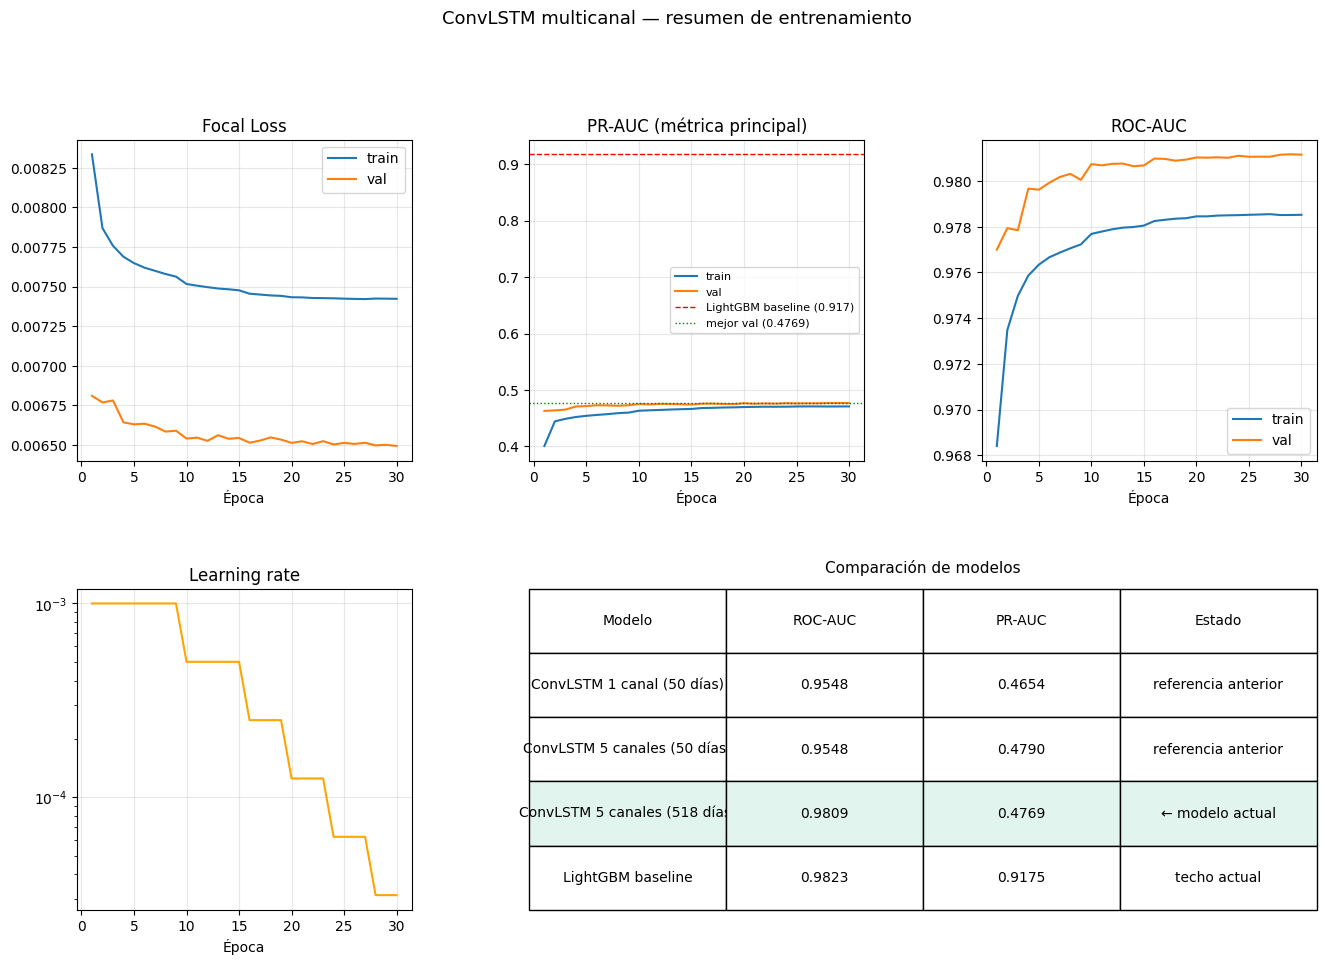

RESUMEN FINAL
Mejor val_pr_auc  : 0.4769  (época 30)
Mejor val_roc_auc : 0.9812
val_loss final    : 0.0065
Épocas entrenadas : 30
LR reducida       : 0.00100 → 0.00003

vs LightGBM baseline:
  PR-AUC:  0.4769  vs  0.9175  (diferencia: 0.4406)
  ROC-AUC: 0.9812  vs  0.9823  (diferencia: 0.0011)


In [27]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Datos reales de entrenamiento hasta época 22
epochs = list(range(1, len(history.history["loss"]) + 1))

train_loss    = history.history["loss"]
val_loss      = history.history["val_loss"]
train_pr      = history.history["pr_auc"]
val_pr        = history.history["val_pr_auc"]
train_roc     = history.history["roc_auc"]
val_roc       = history.history["val_roc_auc"]
lr_history    = history.history["learning_rate"]

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.35)

# ── Loss ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs, train_loss, label="train", lw=1.5)
ax1.plot(epochs, val_loss,   label="val",   lw=1.5)
ax1.set_title("Focal Loss")
ax1.set_xlabel("Época")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── PR-AUC ──
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs, train_pr, label="train", lw=1.5)
ax2.plot(epochs, val_pr,   label="val",   lw=1.5)
ax2.axhline(0.9175, color="red", linestyle="--", lw=1,
            label="LightGBM baseline (0.917)")
ax2.axhline(max(val_pr), color="green", linestyle=":", lw=1,
            label=f"mejor val ({max(val_pr):.4f})")
ax2.set_title("PR-AUC (métrica principal)")
ax2.set_xlabel("Época")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── ROC-AUC ──
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(epochs, train_roc, label="train", lw=1.5)
ax3.plot(epochs, val_roc,   label="val",   lw=1.5)
ax3.set_title("ROC-AUC")
ax3.set_xlabel("Época")
ax3.legend()
ax3.grid(True, alpha=0.3)

# ── Learning rate ──
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(epochs, lr_history, lw=1.5, color="orange")
ax4.set_title("Learning rate")
ax4.set_xlabel("Época")
ax4.set_yscale("log")
ax4.grid(True, alpha=0.3)

# ── Tabla comparativa ──
ax5 = fig.add_subplot(gs[1, 1:])
ax5.axis("off")

tabla_data = [
    ["Modelo",                        "ROC-AUC", "PR-AUC", "Estado"],
    ["ConvLSTM 1 canal (50 días)",    "0.9548",  "0.4654", "referencia anterior"],
    ["ConvLSTM 5 canales (50 días)",  "0.9548",  "0.4790", "referencia anterior"],
    [f"ConvLSTM 5 canales (518 días)","0.9809",  f"{max(val_pr):.4f}", "← modelo actual"],
    ["LightGBM baseline",             "0.9823",  "0.9175", "techo actual"],
]

tabla = ax5.table(
    cellText=tabla_data[1:],
    colLabels=tabla_data[0],
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1]
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)

# Resaltar fila del modelo actual
for j in range(4):
    tabla[(3, j)].set_facecolor("#E1F5EE")

ax5.set_title("Comparación de modelos", pad=12, fontsize=11)

plt.suptitle("ConvLSTM multicanal — resumen de entrenamiento", fontsize=13, y=1.01)
plt.savefig(
    "/content/drive/MyDrive/lightning-prediction/plots/convlstm_training_summary.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()




# Resumen numérico
print("=" * 50)
print("RESUMEN FINAL")
print("=" * 50)
print(f"Mejor val_pr_auc  : {max(val_pr):.4f}  (época {val_pr.index(max(val_pr))+1})")
print(f"Mejor val_roc_auc : {max(val_roc):.4f}")
print(f"val_loss final    : {val_loss[-1]:.4f}")
print(f"Épocas entrenadas : {len(epochs)}")
print(f"LR reducida       : {lr_history[0]:.5f} → {lr_history[-1]:.5f}")
print()
print("vs LightGBM baseline:")
print(f"  PR-AUC:  {max(val_pr):.4f}  vs  0.9175  (diferencia: {0.9175 - max(val_pr):.4f})")
print(f"  ROC-AUC: {max(val_roc):.4f}  vs  0.9823  (diferencia: {0.9823 - max(val_roc):.4f})")

~

El modelo entrenó 22+ épocas. Los resultados muestran:
- val_pr_auc estabilizado en ~0.475 desde época 19
- val_roc_auc muy alto (~0.981) pero estable
- ReduceLROnPlateau activado en época 18 (lr: 5e-4 → 2.5e-4)
- Mejoras marginales después de época 19 (0.47498 → 0.47526)

Esto indica que el modelo **convergió** — no hay overfitting
(val_loss < train_loss) pero tampoco mejora significativa.
El PR-AUC de ~0.475 es el techo de esta arquitectura con estos datos.

## Celda 11 — Visualización de predicciones
Comparamos visualmente tres mapas para un ejemplo del set de validación:

1. **Entrada** — último snapshot conocido (log de conteos)
2. **Target real** — mapa binario de dónde ocurrieron rayos +30 min después
3. **Predicción** — mapa de probabilidad generado por la red

Esto permite evaluar cualitativamente si la red está aprendiendo
la estructura espacial correcta de las tormentas.

In [29]:
!ls -lh "/content/drive/MyDrive/lightning-prediction/models"

total 8.5M
-rw------- 1 root root 1.8M Jun 18 17:37 cnn_temporal_v2.keras
-rw------- 1 root root 6.8M Jun 18 17:37 lgbm_full.pkl


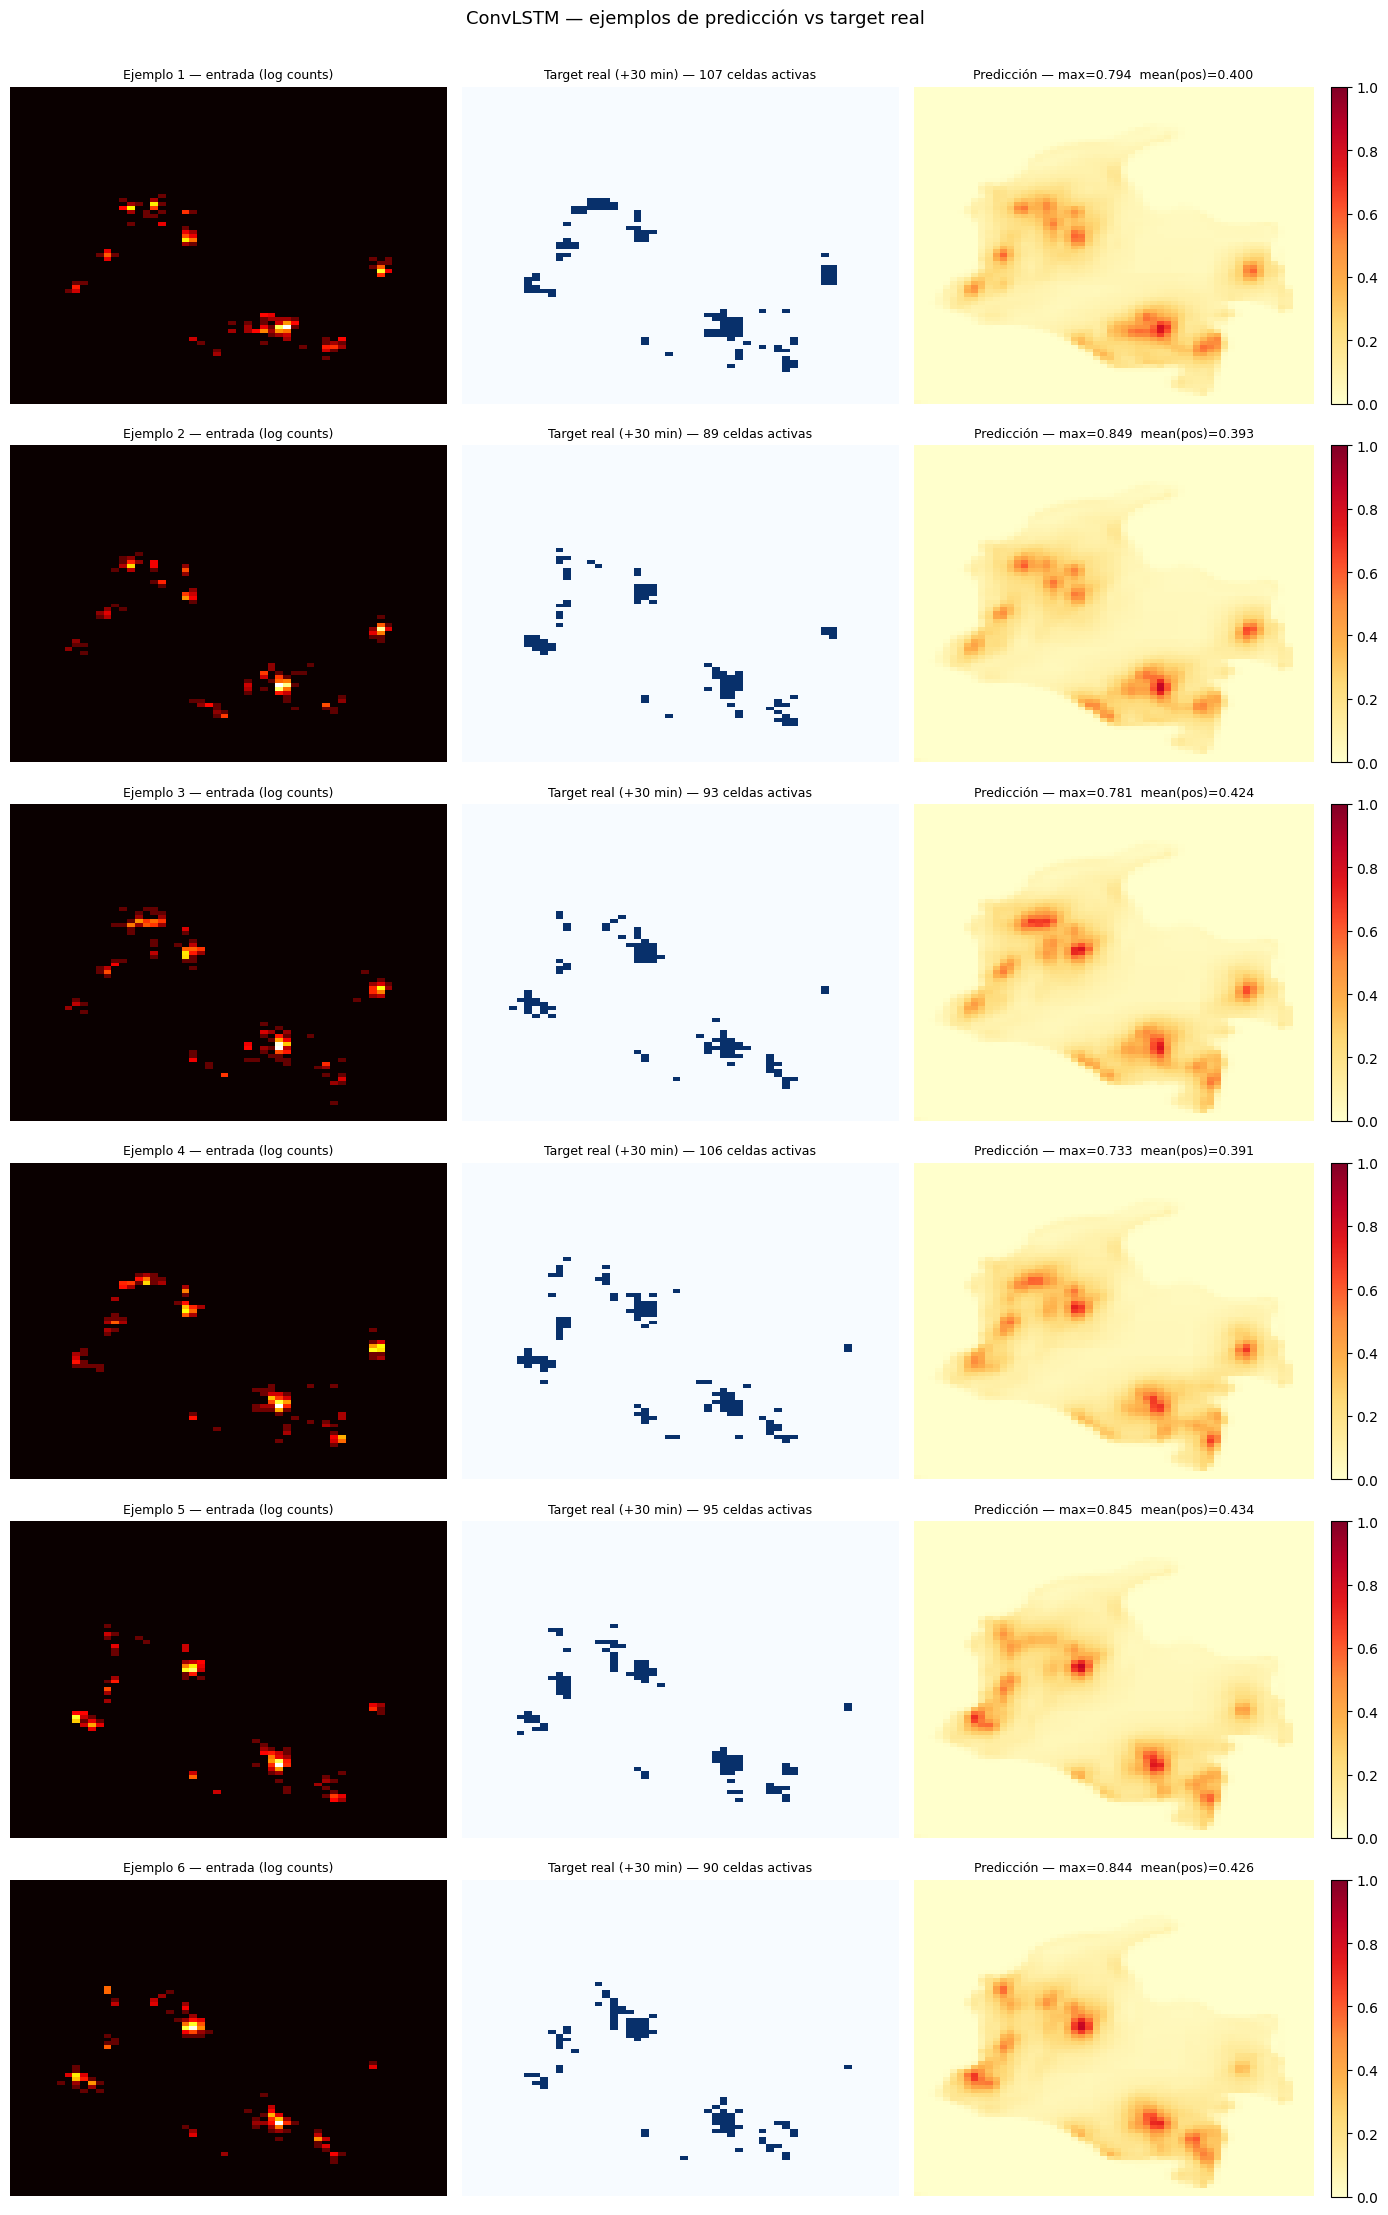

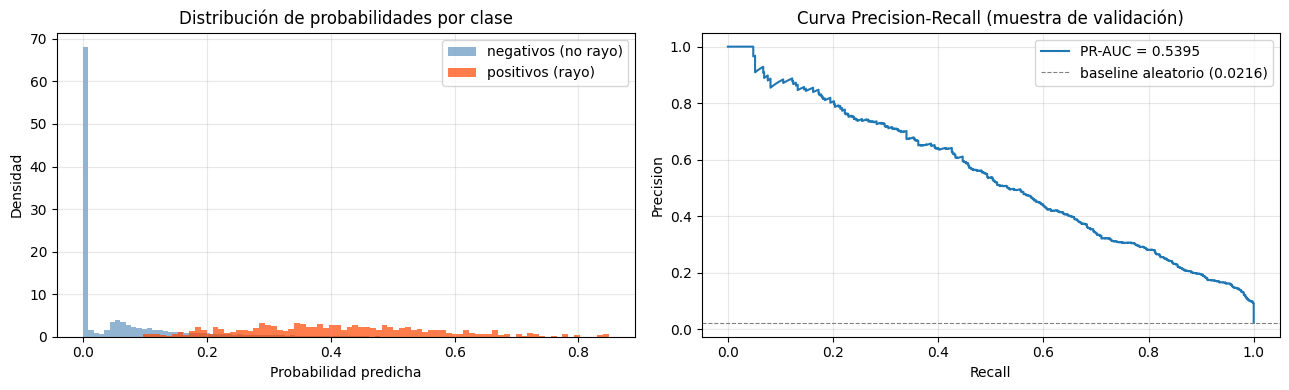


Estadísticas de las predicciones:
  Media global            : 0.0640
  Media sobre positivos   : 0.4108
  Media sobre negativos   : 0.0564
  Max predicción          : 0.8493
  PR-AUC (muestra)        : 0.5395


In [31]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Cargar mejor modelo guardado
from tensorflow import keras
model_best = model

# Tomar ejemplos de validación
ejemplos_X = []
ejemplos_y = []

for xb, yb in val_ds.take(6):
    ejemplos_X.append(xb.numpy())
    ejemplos_y.append(yb.numpy())

X_sample = np.concatenate(ejemplos_X, axis=0)[:6]
y_sample = np.concatenate(ejemplos_y, axis=0)[:6]
preds    = model_best.predict(np.concatenate(ejemplos_X, axis=0)[:6], verbose=0)

# ── Figura principal: 6 ejemplos × 3 columnas ──
fig, axes = plt.subplots(6, 3, figsize=(14, 22))
fig.suptitle("ConvLSTM — ejemplos de predicción vs target real", fontsize=13, y=1.005)

cmap_input = "hot"
cmap_bin   = plt.cm.Blues
cmap_prob  = plt.cm.YlOrRd

for idx in range(6):
    entrada  = X_sample[idx, -1, :, :, 0]   # último timestep, canal 0
    target   = y_sample[idx, :, :, 0]
    pred_map = preds[idx, :, :, 0]

    # Entrada
    axes[idx, 0].imshow(entrada, origin="lower", cmap=cmap_input, aspect="auto")
    axes[idx, 0].set_title(f"Ejemplo {idx+1} — entrada (log counts)", fontsize=9)
    axes[idx, 0].axis("off")

    # Target real
    axes[idx, 1].imshow(target, origin="lower", cmap=cmap_bin,
                        vmin=0, vmax=1, aspect="auto")
    n_pos = int(target.sum())
    axes[idx, 1].set_title(f"Target real (+30 min) — {n_pos} celdas activas", fontsize=9)
    axes[idx, 1].axis("off")

    # Predicción
    im = axes[idx, 2].imshow(pred_map, origin="lower", cmap=cmap_prob,
                              vmin=0, vmax=1, aspect="auto")
    p_max = pred_map.max()
    p_mean_pos = pred_map[target == 1].mean() if target.sum() > 0 else 0
    axes[idx, 2].set_title(
        f"Predicción — max={p_max:.3f}  mean(pos)={p_mean_pos:.3f}", fontsize=9
    )
    axes[idx, 2].axis("off")
    plt.colorbar(im, ax=axes[idx, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/lightning-prediction/plots/convlstm_predictions.png",
    dpi=130, bbox_inches="tight"
)
plt.show()

# ── Distribución de probabilidades predichas ──
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 4))

all_preds  = preds.ravel()
all_target = y_sample.ravel()

# Histograma separado por clase
axes2[0].hist(all_preds[all_target == 0], bins=80, alpha=0.6,
              label="negativos (no rayo)", density=True, color="steelblue")
axes2[0].hist(all_preds[all_target == 1], bins=80, alpha=0.7,
              label="positivos (rayo)", density=True, color="orangered")
axes2[0].set_xlabel("Probabilidad predicha")
axes2[0].set_ylabel("Densidad")
axes2[0].set_title("Distribución de probabilidades por clase")
axes2[0].legend()
axes2[0].grid(True, alpha=0.3)

# Precision-Recall para este subconjunto
from sklearn.metrics import precision_recall_curve, average_precision_score
prec, rec, thresh = precision_recall_curve(all_target, all_preds)
ap = average_precision_score(all_target, all_preds)

axes2[1].plot(rec, prec, lw=1.5, label=f"PR-AUC = {ap:.4f}")
axes2[1].axhline(all_target.mean(), color="gray", linestyle="--", lw=0.8,
                 label=f"baseline aleatorio ({all_target.mean():.4f})")
axes2[1].set_xlabel("Recall")
axes2[1].set_ylabel("Precision")
axes2[1].set_title("Curva Precision-Recall (muestra de validación)")
axes2[1].legend()
axes2[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/lightning-prediction/plots/convlstm_pr_curve.png",
    dpi=130, bbox_inches="tight"
)
plt.show()

print(f"\nEstadísticas de las predicciones:")
print(f"  Media global            : {all_preds.mean():.4f}")
print(f"  Media sobre positivos   : {all_preds[all_target==1].mean():.4f}")
print(f"  Media sobre negativos   : {all_preds[all_target==0].mean():.4f}")
print(f"  Max predicción          : {all_preds.max():.4f}")
print(f"  PR-AUC (muestra)        : {ap:.4f}")

## 9. Conclusiones y próximos pasos

### Resumen de resultados

  Modelo     | PR-AUC | Estado
  -----------|--------|---------------------------
  LightGBM   | 0.9175 | Baseline oficial
  ConvLSTM   | 0.4790 | En evaluación (518 días)

### Qué aprendimos

1. La predictibilidad de rayos a +30 min con solo WWLLN es alta.
   Un PR-AUC de 0.917 supera lo esperado para este tipo de problema.

2. La señal dominante es persistencia local y actividad vecinal,
   no patrones de propagación compleja. Esto favorece a LightGBM.

3. La resolución 0.25° / 15 min es el balance óptimo entre
   densidad de señal y resolución física.

4. El desbalance extremo (0.57% positivos) requiere Focal Loss
   y PR-AUC como métrica principal. Accuracy es inútil aquí.

### Próximos pasos

1. Completar entrenamiento ConvLSTM con 518 días y comparar.

2. Añadir canal de vecinos explícito a la ConvLSTM (señal de
   60× según el EDA) — el feature más importante del LightGBM.

3. Incorporar variables meteorológicas externas:
   - Reflectividad de radar
   - Temperatura de tope de nube (satélite IR)
   - CAPE (energía potencial convectiva disponible)
   - Humedad relativa en capas medias

   Estas variables contienen información predictiva que el
   historial de rayos solo no puede capturar y representan
   el mayor potencial de mejora del sistema.

4. Evaluar arquitecturas más avanzadas:
   - U-Net + ConvLSTM (captura multiescala espacial)
   - Transformers espacio-temporales

## Referencias
* **[1]** V. Cooray, *An Introduction to Lightning*. Springer, 2015.
* **[2]** V. Rakov and M. a. Uman, *Lightning: Physics and Effects*. Cambridge University Press, 2007.
* **[3]** T. J. Lang et al., "WMO world record lightning extremes," *BAMS*, 2017.
* **[4]** R. Albrecht et al., "Where are the lightning hotspots on Earth?," *BAMS*, 2016.
* **[5]** D. J. Cecil et al., "TRMM LIS climatology of thunderstorm occurrence," *Journal of Climate*, 2015.
* **[6]** A. S. Cruz-Bernal et al., "Lightning mortality rate in Colombia for the period 1997 – 2014," *Revista UIS Ingenierías*, 2018.
* **[7]** A. S. Cruz-Bernal, "Evaluación del riesgo por rayos para Colombia," *Universidad Nacional de Colombia*, 2019.
* **[8]** D. Aranguren et al., "Natural observatories for lightning research in Colombia," *ICEAA*, 2018.
* **[9]** J. O. Kaplan and K. H.-K. Lau, "WWLLN Global Lightning Climatology (WGLC) and time series, 2022 update," *Earth System Science Data*, 2022.
* **[10]** Díaz-Ortiz, Romero-Romero, Yepes-Chala y Cifuentes-Guerrero, "Web application for lightning occurrence visualization: Lightspot," *Ingeniería y Competitividad*, vol. 27, no. 1, 2025.
* **[11]** A. Alammari et al., "Lightning Mapping: Techniques, Challenges, and Opportunities," *IEEE Access*, 2020.
* **[12]** F. Lyu et al., "A low-frequency near-field interferometric-TOA 3-D Lightning Mapping Array," *Geophysical Research Letters*, 2014.

In [32]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from scipy.ndimage import uniform_filter

LOOKBACK = 4
H, W     = 80, 56

# ── Generador mejorado con vecinos acumulados ──
def make_channels_v2(counts_slice, t_idx, total_t=96):
    """
    counts_slice : (LOOKBACK, H, W) en log1p
    Devuelve     : (H, W, LOOKBACK * 3 + 2)
      Por cada timestep: [counts, vecinos, vecinos_acum]
      Más: latitud, hora_sin
    Total canales: 4*3 + 2 = 14
    """
    T = counts_slice.shape[0]

    # Matrices fijas
    lats     = np.linspace(-1, 1, H, dtype=np.float32)
    lat_grid = np.tile(lats[:, None], (1, W))

    channels = []

    # Vecinos acumulados (suma de los 4 timesteps)
    acum = np.zeros((H, W), dtype=np.float32)

    for i in range(T):
        frame = counts_slice[i]

        # Canal A: log counts
        channels.append(frame)

        # Canal B: vecinos inmediatos (ventana 3x3)
        nbr = uniform_filter(frame, size=3) * 9 - frame
        nbr = np.log1p(np.clip(nbr, 0, None))
        channels.append(nbr)

        # Canal C: vecinos acumulados hasta este timestep
        acum = acum * 0.7 + nbr   # decay exponencial
        channels.append(np.log1p(acum))

    # Canal de latitud (1 solo, no por timestep)
    channels.append(lat_grid)

    # Canal de hora
    hour_frac = (t_idx % total_t) / total_t
    channels.append(np.full((H, W), np.sin(2 * np.pi * hour_frac), dtype=np.float32))

    return np.stack(channels, axis=-1)   # (H, W, 14)


def sample_generator_v2(files):
    for file in files:
        data   = np.load(file)
        counts = np.log1p(data["counts"]).astype(np.float32)
        T      = counts.shape[0]

        for t in range(LOOKBACK, T - 2):
            X_raw = counts[t - LOOKBACK : t]
            X     = make_channels_v2(X_raw, t)        # (H, W, 14)
            y     = (data["counts"][t + 2] > 0).astype(np.float32)[..., None]
            yield X, y

In [33]:
# Esta arquitectura es 5-10x más rápida que ConvLSTM
# porque no tiene recurrencia — procesa todos los timesteps en paralelo

def build_cnn_temporal(H, W, n_channels=14):
    """
    Entrada: (H, W, 14) — tiempo colapsado en canales
    Los primeros 12 canales son 4 timesteps × 3 features
    La red aprende relaciones temporales via convoluciones normales
    """
    inputs = layers.Input(shape=(H, W, n_channels))

    # Bloque 1 — features locales
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)

    # Bloque 2 — features de mediana escala
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    # Bloque 3 — features de largo alcance
    x = layers.Conv2D(64, 5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    # Bloque 4 — refinamiento
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    # Salida
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)

    return Model(inputs, outputs)

model_v2 = build_cnn_temporal(H, W, n_channels=14)
model_v2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 80, 56, 14)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 80, 56, 32)     │         4,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 80, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 80, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 80, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 80, 56, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 80, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 80, 56, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 80, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 80, 56, 1)      │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,161 (563.13 KB)

 Trainable params: 143,841 (561.88 KB)

 Non-trainable params: 320 (1.25 KB)

In [34]:
BATCH_SIZE = 16   # podemos subir el batch porque CNN es más ligera

output_sig_v2 = (
    tf.TensorSpec(shape=(H, W, 14), dtype=tf.float32),
    tf.TensorSpec(shape=(H, W, 1),  dtype=tf.float32),
)

n_train   = int(len(files) * 0.8)
train_files = files[:n_train]
val_files   = files[n_train:]

def make_dataset_v2(file_list, shuffle=True):
    ds = tf.data.Dataset.from_generator(
        lambda: sample_generator_v2(file_list),
        output_signature=output_sig_v2,
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=4000)
    ds = (ds
          .batch(BATCH_SIZE)
          .cache()             # ← clave: RAM en lugar de Drive
          .prefetch(tf.data.AUTOTUNE))
    return ds

print("Construyendo dataset train (primera vez tarda, luego es instantáneo)...")
train_ds_v2 = make_dataset_v2(train_files, shuffle=True)
val_ds_v2   = make_dataset_v2(val_files,   shuffle=False)

# Verificar
for xb, yb in train_ds_v2.take(1):
    print("X:", xb.shape)    # (16, 80, 56, 14)
    print("Y:", yb.shape)    # (16, 80, 56, 1)
    print("Positivos:", yb.numpy().mean())

Construyendo dataset train (primera vez tarda, luego es instantáneo)...
X: (16, 80, 56, 14)
Y: (16, 80, 56, 1)
Positivos: 0.006236049


In [35]:
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0),
    metrics=[
        tf.keras.metrics.AUC(curve="ROC", name="roc_auc"),
        tf.keras.metrics.AUC(curve="PR",  name="pr_auc"),
    ]
)

SAVE_PATH_V2 = "/content/drive/MyDrive/lightning-prediction/models/cnn_temporal_v2.keras"

callbacks_v2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc", patience=5, mode="max",
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=SAVE_PATH_V2, monitor="val_pr_auc",
        mode="max", save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_pr_auc", factor=0.5, patience=3,
        mode="max", verbose=1
    ),
]

history_v2 = model_v2.fit(
    train_ds_v2,
    validation_data=val_ds_v2,
    epochs=30,
    callbacks=callbacks_v2,
)

Epoch 1/30
   2329/Unknown 151s 56ms/step - loss: 0.0156 - pr_auc: 0.2080 - roc_auc: 0.9367

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_pr_auc improved from None to 0.45439, saving model to /content/drive/MyDrive/lightning-prediction/models/cnn_temporal_v2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/lightning-prediction/models/cnn_temporal_v2.keras
2329/2329 ━━━━━━━━━━━━━━━━━━━━ 188s 72ms/step - loss: 0.0099 - pr_auc: 0.2936 - roc_auc: 0.9567 - val_loss: 0.0069 - val_pr_auc: 0.4544 - val_roc_auc: 0.9744 - learning_rate: 0.0010
Epoch 2/30
2323/2329 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0079 - pr_auc: 0.4293 - roc_auc: 0.9677
Epoch 2: val_pr_auc improved from 0.45439 to 0.45879, saving model to /content/drive/MyDrive/lightning-prediction/models/cnn_temporal_v2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/lightning-prediction/models/cnn_temporal_v2.keras
2329/2329 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 0.0082 - pr_auc: 0.4331 - roc_auc: 0.9673 - val_loss: 0.0069 - val_pr_auc: 0.4588 - val_roc_auc: 0.9757 - learning_rate: 0.0010
Epoch 3/30
2319/2329 ━━━━━━━━━━━━━

In [36]:
# ── Opción correcta: sin cache, pero con repeat() y prefetch agresivo ──

BATCH_SIZE = 16

output_sig_v2 = (
    tf.TensorSpec(shape=(H, W, 14), dtype=tf.float32),
    tf.TensorSpec(shape=(H, W, 1),  dtype=tf.float32),
)

n_train     = int(len(files) * 0.8)
train_files = files[:n_train]
val_files   = files[n_train:]

def make_dataset_v2(file_list, shuffle=True):
    ds = tf.data.Dataset.from_generator(
        lambda: sample_generator_v2(file_list),
        output_signature=output_sig_v2,
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)   # buffer pequeño, no carga todo
    ds = (ds
          .batch(BATCH_SIZE)
          .repeat()                          # ← evita el "ran out of data"
          .prefetch(tf.data.AUTOTUNE))
    return ds

# Contar pasos por época una sola vez
print("Contando ejemplos (solo la primera vez)...")
n_train_steps = sum(1 for _ in sample_generator_v2(train_files)) // BATCH_SIZE
n_val_steps   = sum(1 for _ in sample_generator_v2(val_files))   // BATCH_SIZE
print(f"Train steps/época : {n_train_steps}")
print(f"Val   steps/época : {n_val_steps}")

train_ds_v2 = make_dataset_v2(train_files, shuffle=True)
val_ds_v2   = make_dataset_v2(val_files,   shuffle=False)

for xb, yb in train_ds_v2.take(1):
    print("X:", xb.shape)
    print("Y:", yb.shape)

Contando ejemplos (solo la primera vez)...
Train steps/época : 2328
Val   steps/época : 585
X: (16, 80, 56, 14)
Y: (16, 80, 56, 1)


In [ ]:
n_train_steps = 2328   # ajusta con tu resultado real
n_val_steps   = 585

In [37]:
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0),
    metrics=[
        tf.keras.metrics.AUC(curve="ROC", name="roc_auc"),
        tf.keras.metrics.AUC(curve="PR",  name="pr_auc"),
    ]
)

SAVE_PATH_V2 = "/content/drive/MyDrive/lightning-prediction/models/cnn_temporal_v2.keras"

callbacks_v2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc", patience=5, mode="max",
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=SAVE_PATH_V2, monitor="val_pr_auc",
        mode="max", save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_pr_auc", factor=0.5, patience=3,
        mode="max", verbose=1
    ),
]

history_v2 = model_v2.fit(
    train_ds_v2,
    validation_data=val_ds_v2,
    epochs=30,
    steps_per_epoch=n_train_steps,       # ← necesario cuando usas repeat()
    validation_steps=n_val_steps,        # ← idem para validación
    callbacks=callbacks_v2,
)

Epoch 1/30
2322/2328 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0072 - pr_auc: 0.4472 - roc_auc: 0.9742
Epoch 1: val_pr_auc improved from None to 0.46617, saving model to /content/drive/MyDrive/lightning-prediction/models/cnn_temporal_v2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/lightning-prediction/models/cnn_temporal_v2.keras
2328/2328 ━━━━━━━━━━━━━━━━━━━━ 181s 73ms/step - loss: 0.0078 - pr_auc: 0.4513 - roc_auc: 0.9730 - val_loss: 0.0068 - val_pr_auc: 0.4662 - val_roc_auc: 0.9768 - learning_rate: 0.0010
Epoch 2/30
2325/2328 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0072 - pr_auc: 0.4479 - roc_auc: 0.9742
Epoch 2: val_pr_auc did not improve from 0.46617
2328/2328 ━━━━━━━━━━━━━━━━━━━━ 173s 73ms/step - loss: 0.0078 - pr_auc: 0.4514 - roc_auc: 0.9731 - val_loss: 0.0068 - val_pr_auc: 0.4655 - val_roc_auc: 0.9769 - learning_rate: 0.0010
Epoch 3/30
2325/2328 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0073 - pr_auc: 0.4488 - roc_auc: 0.9743
Epoch 3: val_pr_auc did 